In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('mystyle')
import time
import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
# df = pd.read_csv('data/bahrain_2023_race_telemetry.csv')

# names = df['name_acronym'].unique()

# # No need to extract columns separately, just filter the df directly
# telem = df[['speed', 'rpm', 'n_gear', 'throttle']].loc[df['speed'] > 0]

In [5]:
df = pd.read_hdf("f1_data/9158_car_data_2023_Singapore_Practice.h5", key="car_data")

In [6]:
df

,date,session_key,throttle,speed,brake,rpm,meeting_key,driver_number,n_gear,drs
0,2023-09-15 09:15:02.731000+00:00,9158,0,0,0,0,1219,1,0,9
1,2023-09-15 09:15:02.971000+00:00,9158,0,0,0,0,1219,1,0,9
2,2023-09-15 09:15:03.211000+00:00,9158,0,0,0,0,1219,1,0,9
3,2023-09-15 09:15:03.491000+00:00,9158,0,0,0,0,1219,1,0,9
4,2023-09-15 09:15:03.771000+00:00,9158,0,0,0,0,1219,1,0,9
...,...,...,...,...,...,...,...,...,...,...
360515,2023-09-15 10:37:06.748000+00:00,9158,0,0,0,0,1219,81,0,8
360516,2023-09-15 10:37:06.988000+00:00,9158,0,0,0,0,1219,81,0,8
360517,2023-09-15 10:37:07.308000+00:00,9158,0,0,0,0,1219,81,0,8
360518,2023-09-15 10:37:07.548000+00:00,9158,0,0,0,0,1219,81,0,8


In [ ]:
import json
drivers = json.load(open("drivers.json"))
drivers["by_year_and_number"]["2023"]["81"]["full_name"] 

'Oscar PIASTRI'

In [ ]:
drivers["by_acronym"]["VER"]["years_active"]

[2023, 2024, 2025]

In [4]:
telem

,speed,rpm,n_gear,throttle
3559,1,3238,1,0
3560,3,3397,1,0
3561,4,3508,1,0
3562,5,3610,1,0
3563,7,3651,1,0
...,...,...,...,...
360411,28,4179,1,0
360412,24,4108,1,0
360413,12,3816,1,0
360414,10,4097,1,0


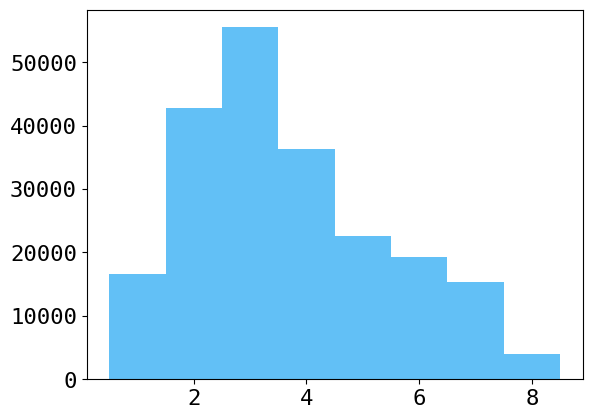

In [5]:
plt.hist(telem['n_gear'], range=(0.5, 8.5), bins=8);

In [10]:
names

array(['VER', 'SAR', 'NOR', 'GAS', 'PER', 'ALO', 'LEC', 'STR', 'MAG',
       'TSU', 'ALB', 'ZHO', 'HUL', 'OCO', 'LAW', 'HAM', 'SAI', 'RUS',
       'BOT', 'PIA'], dtype=object)

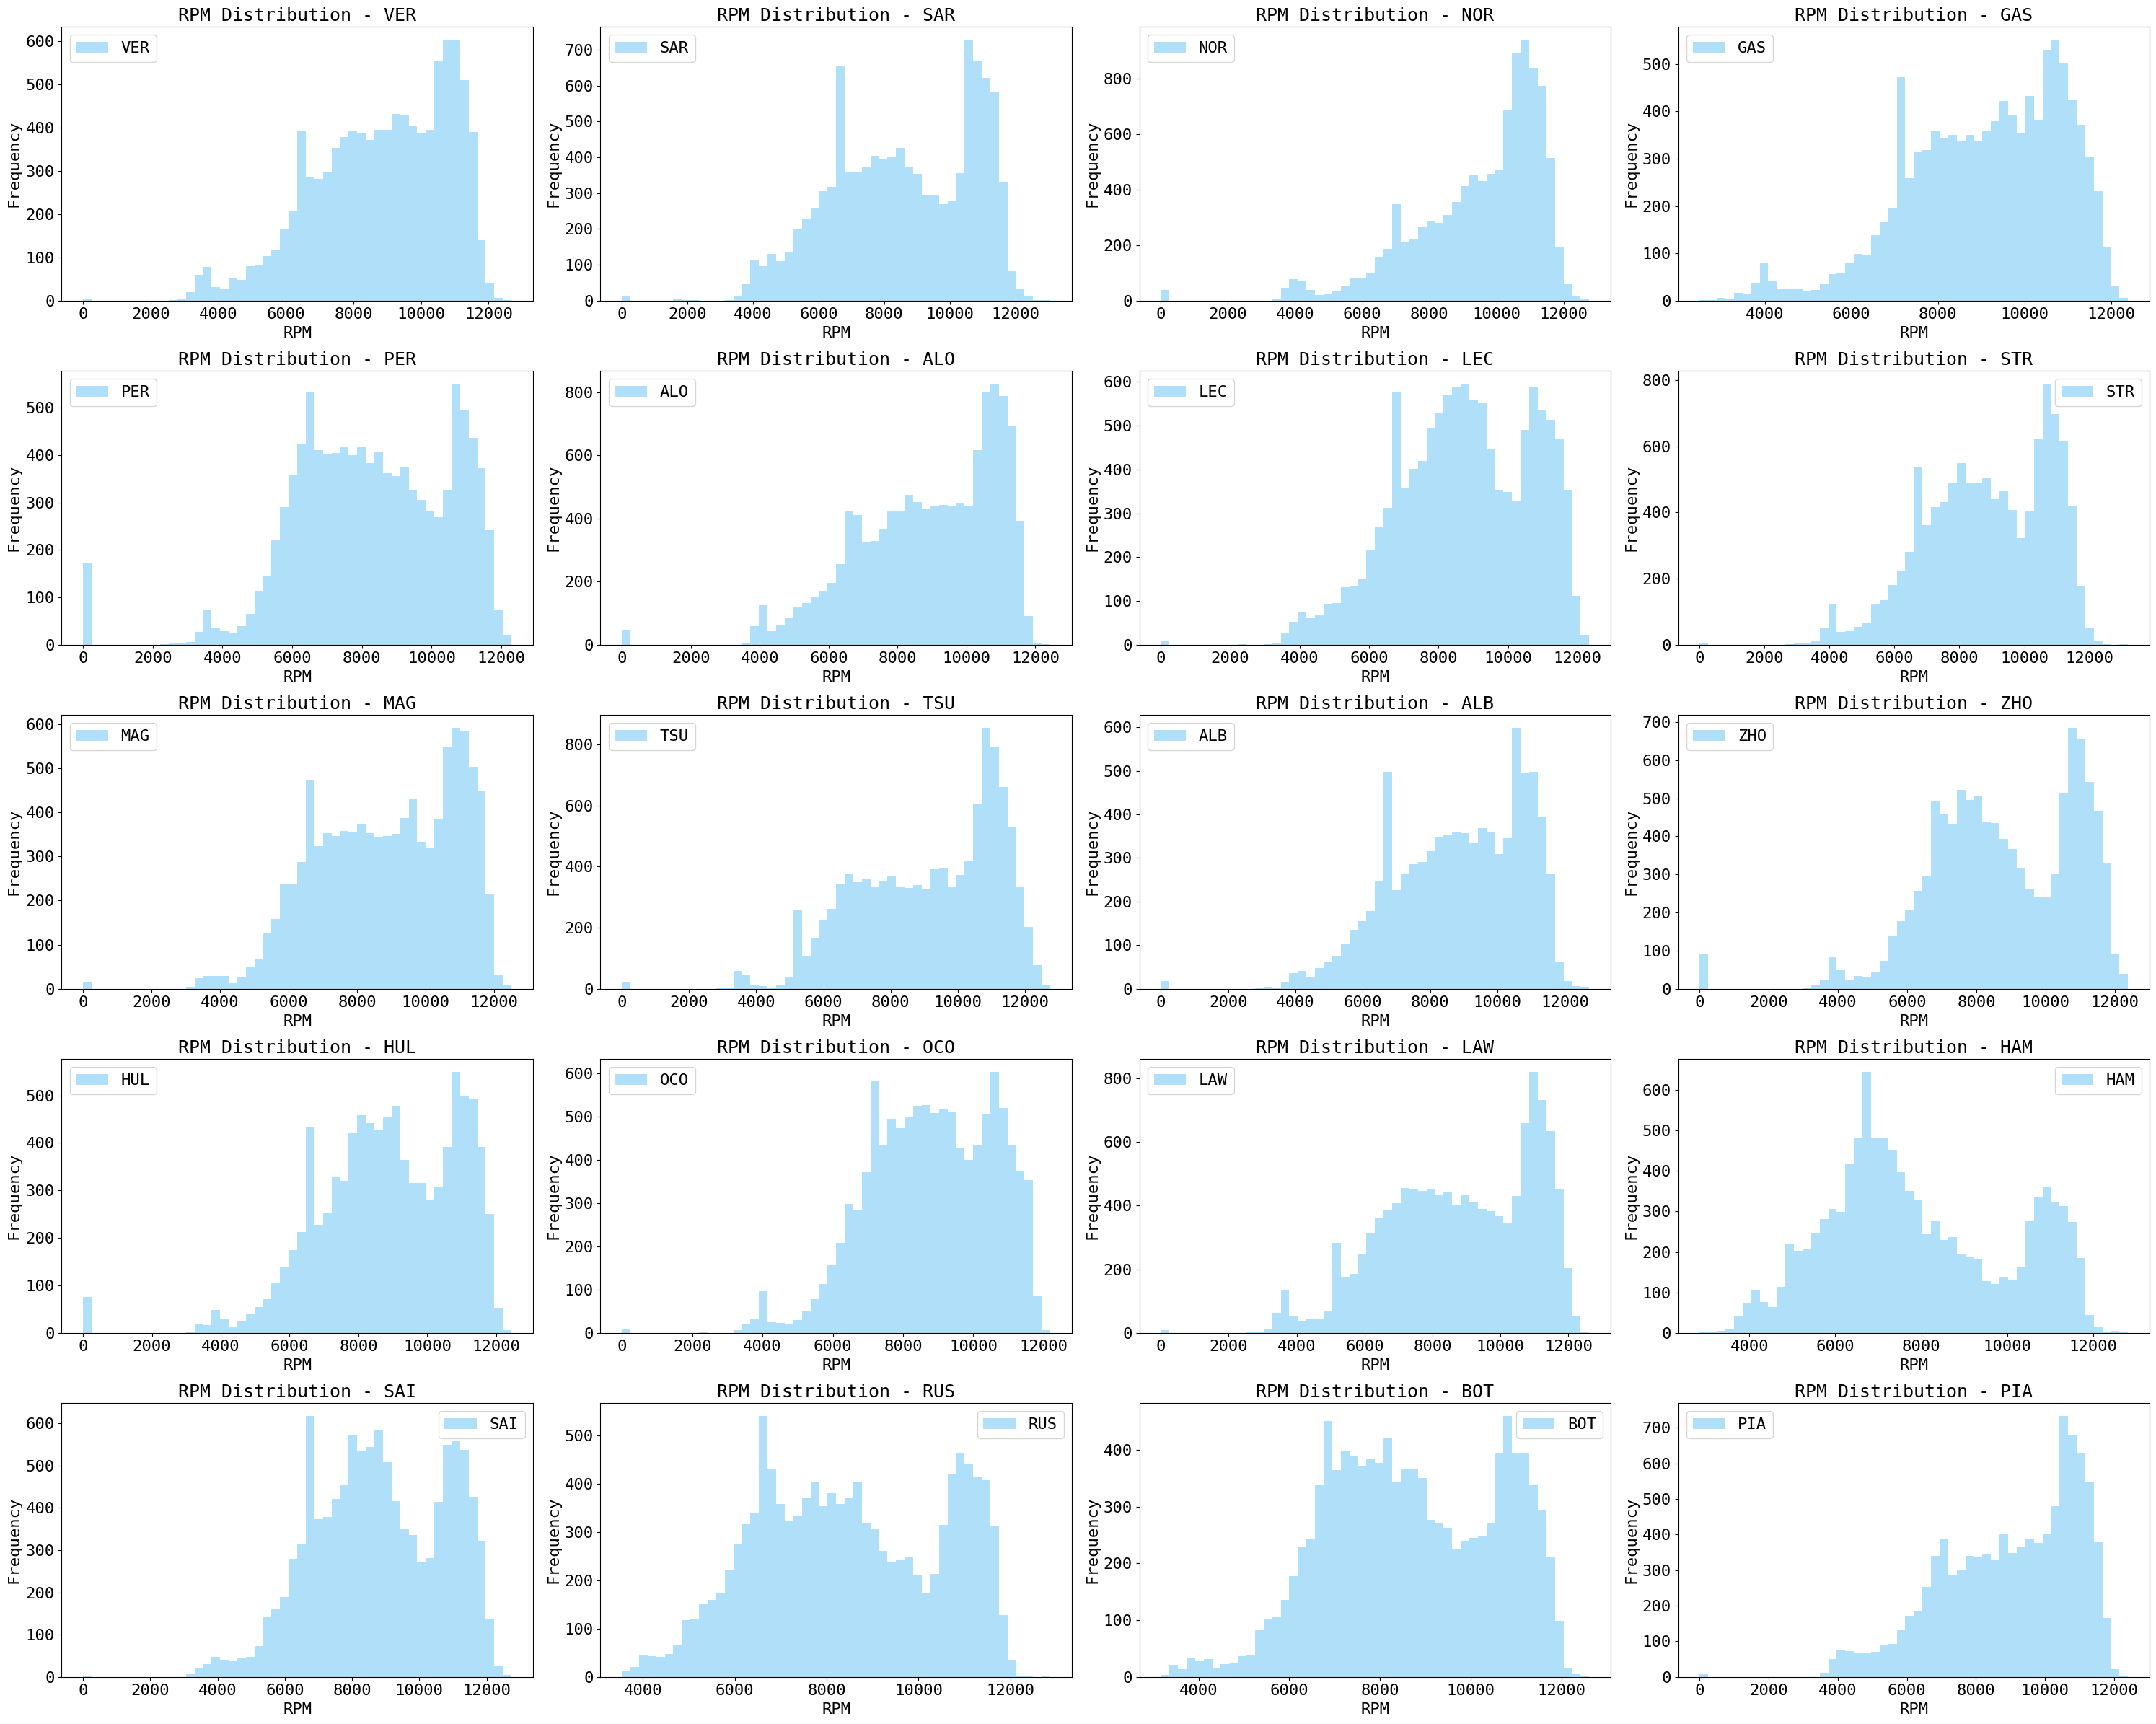

In [24]:
fig, ax = plt.subplots(nrows=5, ncols=4, figsize=(30, 24))
ax = ax.flatten()
for i, name in enumerate(names):
    name_speed = telem['rpm'].loc[df['name_acronym'] == name]
    ax[i].hist(name_speed, bins=50, alpha=0.5, label=name)
    ax[i].set_xlabel('RPM')
    ax[i].set_ylabel('Frequency')
    ax[i].set_title(f'RPM Distribution - {name}')
    ax[i].legend()
plt.tight_layout()

In [8]:
scaler = StandardScaler()
telem_scaled = scaler.fit_transform(telem)

In [19]:
pca = PCA(n_components=2)
y_pcs = pca.fit_transform(telem_scaled)

In [ ]:
# # Random sample of 50k rows, fit on that, transform all
# idx = np.random.choice(len(telem_scaled), 50_000, replace=False)
# sample = telem_scaled[idx]

# reducer = umap.UMAP(
#     n_neighbors=30, 
#     min_dist=0.1, 
#     n_components=2,
#     low_memory=True,    # important for large datasets
#     random_state=42
# )
# reducer.fit(sample)  # fit on sample
# y_umap = reducer.transform(sample)  # transform full dataset

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [20]:
reducer = umap.UMAP(n_components=2)
y_umap = reducer.fit_transform(telem_scaled)

In [22]:
start = time.time()

km = KMeans(
    n_clusters=20,
    init='k-means++',   # smarter initialization than random
    n_init=20,          # run 20 times, keep best — default is only 10
    max_iter=500,       # give it room to converge
    random_state=42
)
km_labels = km.fit_predict(telem_scaled)

end = time.time()

print(f"Time used by K-Means: {(end - start) * 1000:.1f} ms")

Time used by K-Means: 4276.8 ms


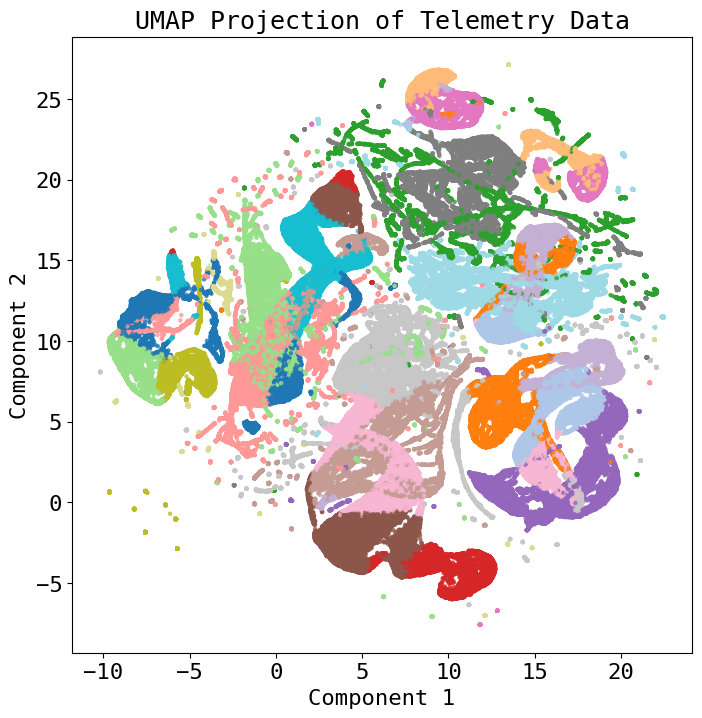

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.scatter(y_umap[:, 0], y_umap[:, 1], s=5, c=km_labels, cmap='tab20', alpha=0.7)
ax.set_title('UMAP Projection of Telemetry Data');